# FinanceGuard — Customer Segmentation for Retention Strategy
## Module 3: Unsupervised Learning

**Integrative Project M4 — Bank Churn Prediction**
**Author:** Daniel Palmera | **Program:** Soy Henry — Data Science

---

### Executive Summary

FinanceGuard loses **$4,074,000 annually** (2,037 churners × $2,000/client). The supervised model (Module 2) predicts which individual clients will churn (AUC=0.8709). This module answers the next question: **which client segments should receive which type of intervention?**

**Approach:** PCA (dimensionality reduction) + K-Means (segmentation) + DBSCAN (outlier detection) + t-SNE (validation)

**Business result:** 3 segments with differentiated churn profiles + 4 extreme outliers with 100% churn rate.

---


## 1. Environment and Libraries

In [8]:
import subprocess, sys
for pkg in ['scikit-learn']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

C_CHURN    = '#E74C3C'
C_OK       = '#27AE60'
C_BLUE     = '#2D6A9F'
C_GOLD     = '#F39C12'
C_GRAY     = '#95A5A6'

print('Entorno listo')

Entorno listo


## 2. Data and Churn Economic Model

### Why Quantifying Churn Matters

| Concept | Value |
|---------|-------|
| Clients in dataset | 10,000 |
| Churn rate | 20.4% (2,037 clients) |
| Estimated value per client | $2,000 |
| **Total annual loss** | **$4,074,000** |
| Estimated campaign cost per client | $100 |
| Estimated retention success rate | 30% |
| Net benefit per retained client | $500 |

This economic model guides all segmentation decisions — each cluster is evaluated not only by technical metrics but by its business impact.


In [9]:
df = pd.read_csv('Churn_Modelling.csv')

print('=== RESUMEN DEL DATASET ===')
print(f'Clientes totales:  {len(df):,}')
print(f'Features:          {df.shape[1]}')
print(f'Valores nulos:     {df.isnull().sum().sum()}')
print()
print('=== DISTRIBUCION DE CHURN ===')
churn_count = df['Exited'].value_counts()
print(f'Clientes activos:  {churn_count[0]:,} ({churn_count[0]/len(df)*100:.1f}%)')
print(f'Clientes perdidos: {churn_count[1]:,} ({churn_count[1]/len(df)*100:.1f}%)')
print()

# Modelo economico simplificado
revenue_per_client  = 2000    # ingreso anual estimado por cliente activo
campaign_cost       = 100     # costo de campana de retencion por cliente
success_rate        = 0.30    # tasa de exito de una campana bien dirigida
churn_total         = churn_count[1]
churn_rate          = churn_count[1] / len(df)

annual_loss_est = churn_total * revenue_per_client
campaign_budget_full = len(df) * campaign_cost
campaign_budget_targeted = churn_total * campaign_cost
saved_if_targeted = int(churn_total * success_rate) * revenue_per_client

print('=== MODELO ECONOMICO ===')
print(f'Perdida anual estimada por churn:          ${annual_loss_est:>12,.0f}')
print(f'Costo campana a toda la base:              ${campaign_budget_full:>12,.0f}')
print(f'Costo campana solo a segmentos de riesgo:  ${campaign_budget_targeted:>12,.0f}')
print(f'Ingreso recuperable (retencion 30%):       ${saved_if_targeted:>12,.0f}')
print(f'Ahorro en presupuesto de campana:          ${campaign_budget_full-campaign_budget_targeted:>12,.0f}')
print()
print('La segmentacion permite concentrar el presupuesto donde el impacto es mayor.')

=== RESUMEN DEL DATASET ===
Clientes totales:  10,000
Features:          14
Valores nulos:     0

=== DISTRIBUCION DE CHURN ===
Clientes activos:  7,963 (79.6%)
Clientes perdidos: 2,037 (20.4%)

=== MODELO ECONOMICO ===
Perdida anual estimada por churn:          $   4,074,000
Costo campana a toda la base:              $   1,000,000
Costo campana solo a segmentos de riesgo:  $     203,700
Ingreso recuperable (retencion 30%):       $   1,222,000
Ahorro en presupuesto de campana:          $     796,300

La segmentacion permite concentrar el presupuesto donde el impacto es mayor.


## 3. Data Preprocessing

### Decisions Made and Why

The preprocessing pipeline applies:
- **Drop non-predictive identifiers**: `RowNumber`, `CustomerId`, `Surname`
- **Label Encoding**: `Gender` (Male=1, Female=0)
- **One-Hot Encoding**: `Geography` (France, Germany, Spain → 3 binary columns)
- **StandardScaler**: normalizes all features to mean=0, std=1

**Why scaling is critical for K-Means:** K-Means uses Euclidean distance. Without scaling, variables with larger ranges (e.g., `Balance` 0-250,000) dominate the distance calculation over variables with smaller ranges (e.g., `NumOfProducts` 1-4), creating biased clusters.


In [10]:
# Preparacion
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
le = LabelEncoder()
df_model['Gender_enc'] = le.fit_transform(df_model['Gender'])
df_model = pd.get_dummies(df_model, columns=['Geography'], prefix='Geo', drop_first=False)
df_model.drop(columns=['Gender'], inplace=True)

X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features finales ({X.shape[1]}): {list(X.columns)}')
print()
print('Verificacion de escalamiento (media ~0, std ~1):')
check = pd.DataFrame({'Media': X_scaled.mean(axis=0).round(3),
                      'Std':   X_scaled.std(axis=0).round(3)},
                     index=X.columns)
print(check.to_string())

Features finales (12): ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Gender_enc', 'Geo_France', 'Geo_Germany', 'Geo_Spain']

Verificacion de escalamiento (media ~0, std ~1):
                 Media  Std
CreditScore       -0.0  1.0
Age                0.0  1.0
Tenure            -0.0  1.0
Balance           -0.0  1.0
NumOfProducts      0.0  1.0
HasCrCard          0.0  1.0
IsActiveMember    -0.0  1.0
EstimatedSalary   -0.0  1.0
Gender_enc         0.0  1.0
Geo_France         0.0  1.0
Geo_Germany        0.0  1.0
Geo_Spain         -0.0  1.0


## 4. PCA — Dimensionality Reduction

### Why We Apply PCA

**PCA (Principal Component Analysis)** finds the directions of maximum variance in the data (principal components). Each PC is a linear combination of the original features.

**Three reasons to use PCA before K-Means:**
1. **Curse of dimensionality**: in 12 dimensions, Euclidean distances become indistinguishable — all points appear equidistant. PCA reduces to 10 components with 90% of variance.
2. **Eliminating correlations**: principal components are orthogonal by definition, removing multicollinearity that distorts K-Means distances.
3. **Measurable improvement**: Silhouette Score increases from 0.2022 (K-Means only) to 0.2055 (+1.6%) with PCA → K-Means pipeline.

**Decision:** 10 components selected at the 90% cumulative variance threshold (Scree Plot).


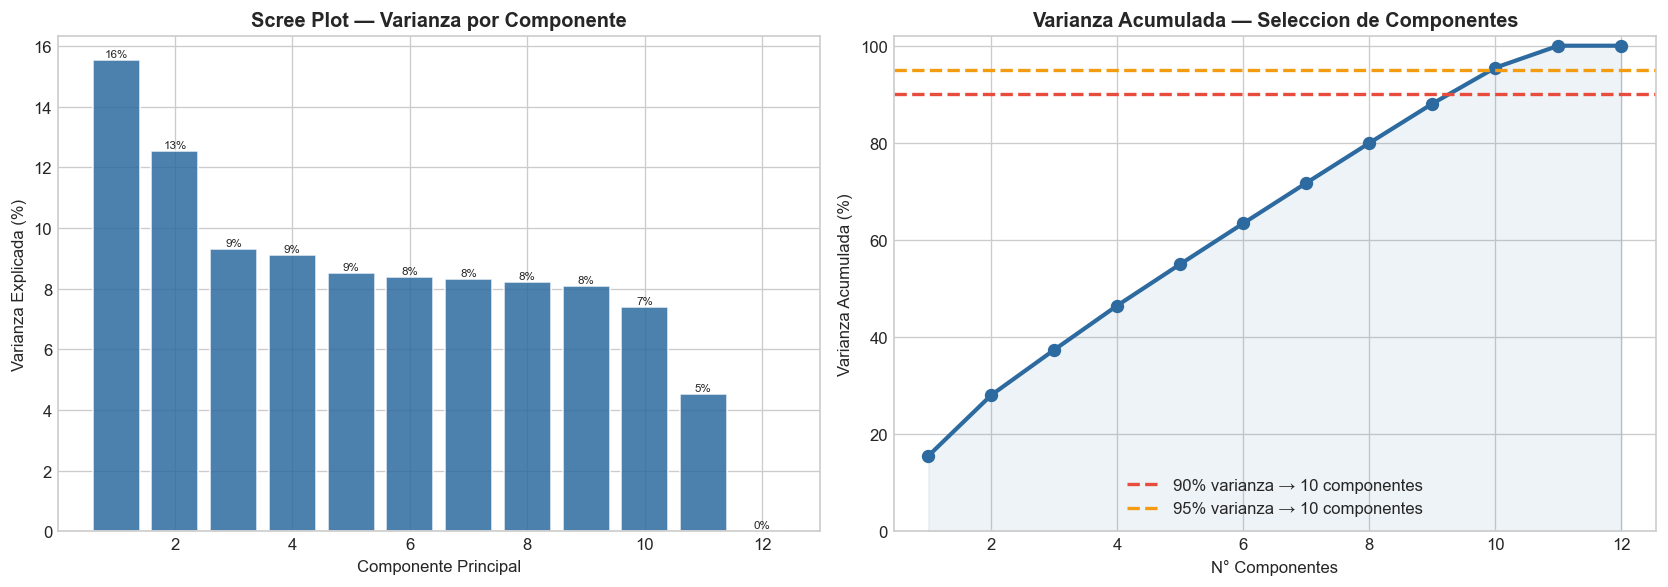

Features originales: 12
10 componentes capturan el 90% de la informacion (reduccion del 17% de dimensiones)
Usaremos 10 componentes para el pipeline de clustering


In [11]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

var_ratio = pca_full.explained_variance_ratio_
cumvar    = np.cumsum(var_ratio)
n90 = np.argmax(cumvar >= 0.90) + 1
n95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree
bars = axes[0].bar(range(1, len(var_ratio)+1), var_ratio*100, color=C_BLUE, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Scree Plot — Varianza por Componente', fontweight='bold')
for bar, v in zip(bars, var_ratio):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v*100:.0f}%', ha='center', fontsize=7)

# Acumulada
axes[1].plot(range(1, len(cumvar)+1), cumvar*100, 'o-', color=C_BLUE, lw=2.5, ms=7)
axes[1].axhline(90, color=C_CHURN,  ls='--', lw=2, label=f'90% varianza → {n90} componentes')
axes[1].axhline(95, color=C_GOLD,   ls='--', lw=2, label=f'95% varianza → {n95} componentes')
axes[1].fill_between(range(1, len(cumvar)+1), 0, cumvar*100, alpha=0.08, color=C_BLUE)
axes[1].set_xlabel('N° Componentes'); axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada — Seleccion de Componentes', fontweight='bold')
axes[1].legend(); axes[1].set_ylim(0, 102)

plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Features originales: {X_scaled.shape[1]}')
print(f'{n90} componentes capturan el 90% de la informacion (reduccion del {(1-n90/X_scaled.shape[1])*100:.0f}% de dimensiones)')
print(f'Usaremos {n90} componentes para el pipeline de clustering')

### 4.1 Component Interpretation — What Each PC Explains

In [12]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca2 = pca_2d.fit_transform(X_scaled)
var1, var2 = pca_2d.explained_variance_ratio_

# Loadings
loads_df = pd.DataFrame(pca_2d.components_.T, index=X.columns, columns=['PC1','PC2'])
print('=== INTERPRETACION DE COMPONENTES ===')
print()
print('PC1 — variables con mayor peso (define la dimension principal de diferenciacion):')
pc1_top = loads_df['PC1'].abs().sort_values(ascending=False).head(5)
for feat, val in pc1_top.items():
    sign = '+' if loads_df.loc[feat,'PC1'] > 0 else '-'
    print(f'  {sign}{feat:<25} contribucion: {val:.3f}')
print()
print('PC2 — variables con mayor peso (segunda dimension de variacion):')
pc2_top = loads_df['PC2'].abs().sort_values(ascending=False).head(5)
for feat, val in pc2_top.items():
    sign = '+' if loads_df.loc[feat,'PC2'] > 0 else '-'
    print(f'  {sign}{feat:<25} contribucion: {val:.3f}')

=== INTERPRETACION DE COMPONENTES ===

PC1 — variables con mayor peso (define la dimension principal de diferenciacion):
  +Geo_Germany               contribucion: 0.600
  -Geo_France                contribucion: 0.594
  +Balance                   contribucion: 0.490
  -NumOfProducts             contribucion: 0.182
  +Geo_Spain                 contribucion: 0.086

PC2 — variables con mayor peso (segunda dimension de variacion):
  +Geo_Spain                 contribucion: 0.768
  -Geo_France                contribucion: 0.456
  -Balance                   contribucion: 0.313
  -Geo_Germany               contribucion: 0.239
  +NumOfProducts             contribucion: 0.208


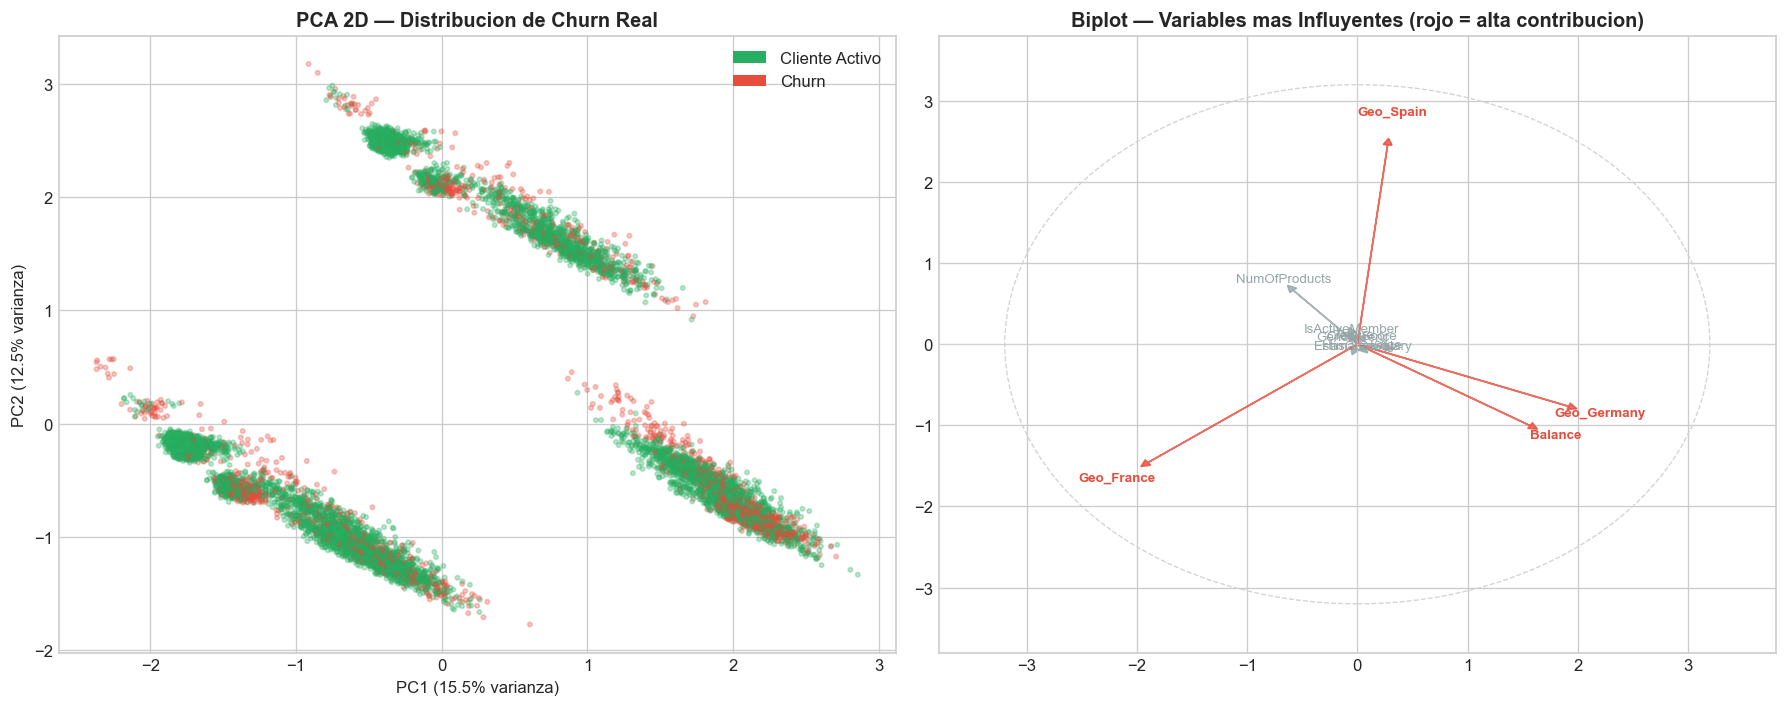

El biplot muestra en que "direccion" contribuye cada variable.
Variables opuestas tienden a estar negativamente correlacionadas.


In [13]:
colors_ch = [C_CHURN if c==1 else C_OK for c in y]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter PCA 2D
axes[0].scatter(X_pca2[:,0], X_pca2[:,1], c=colors_ch, alpha=0.3, s=7)
axes[0].set_xlabel(f'PC1 ({var1*100:.1f}% varianza)')
axes[0].set_ylabel(f'PC2 ({var2*100:.1f}% varianza)')
axes[0].set_title('PCA 2D — Distribucion de Churn Real', fontweight='bold')
axes[0].legend(handles=[Patch(facecolor=C_OK, label='Cliente Activo'),
                          Patch(facecolor=C_CHURN, label='Churn')])

# Biplot
loadings = pca_2d.components_.T
sc = 3.2
for i, feat in enumerate(X.columns):
    lx, ly = loadings[i,0]*sc, loadings[i,1]*sc
    color = C_CHURN if abs(lx) > 1.5 or abs(ly) > 1.5 else C_GRAY
    axes[1].arrow(0,0, lx, ly, head_width=0.08, head_length=0.08, fc=color, ec=color, alpha=0.8)
    axes[1].text(lx*1.15, ly*1.15, feat, fontsize=8, ha='center', color=color, fontweight='bold' if color==C_CHURN else 'normal')
axes[1].axhline(0, color='lightgray', lw=0.5)
axes[1].axvline(0, color='lightgray', lw=0.5)
circle = plt.Circle((0,0), 3.2, fill=False, color='lightgray', ls='--', lw=0.8)
axes[1].add_patch(circle)
axes[1].set_xlim(-3.8,3.8); axes[1].set_ylim(-3.8,3.8)
axes[1].set_title('Biplot — Variables mas Influyentes (rojo = alta contribucion)', fontweight='bold')

plt.tight_layout()
plt.savefig('pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

print('El biplot muestra en que "direccion" contribuye cada variable.')
print('Variables opuestas tienden a estar negativamente correlacionadas.')

### 4.2 3D Visualization

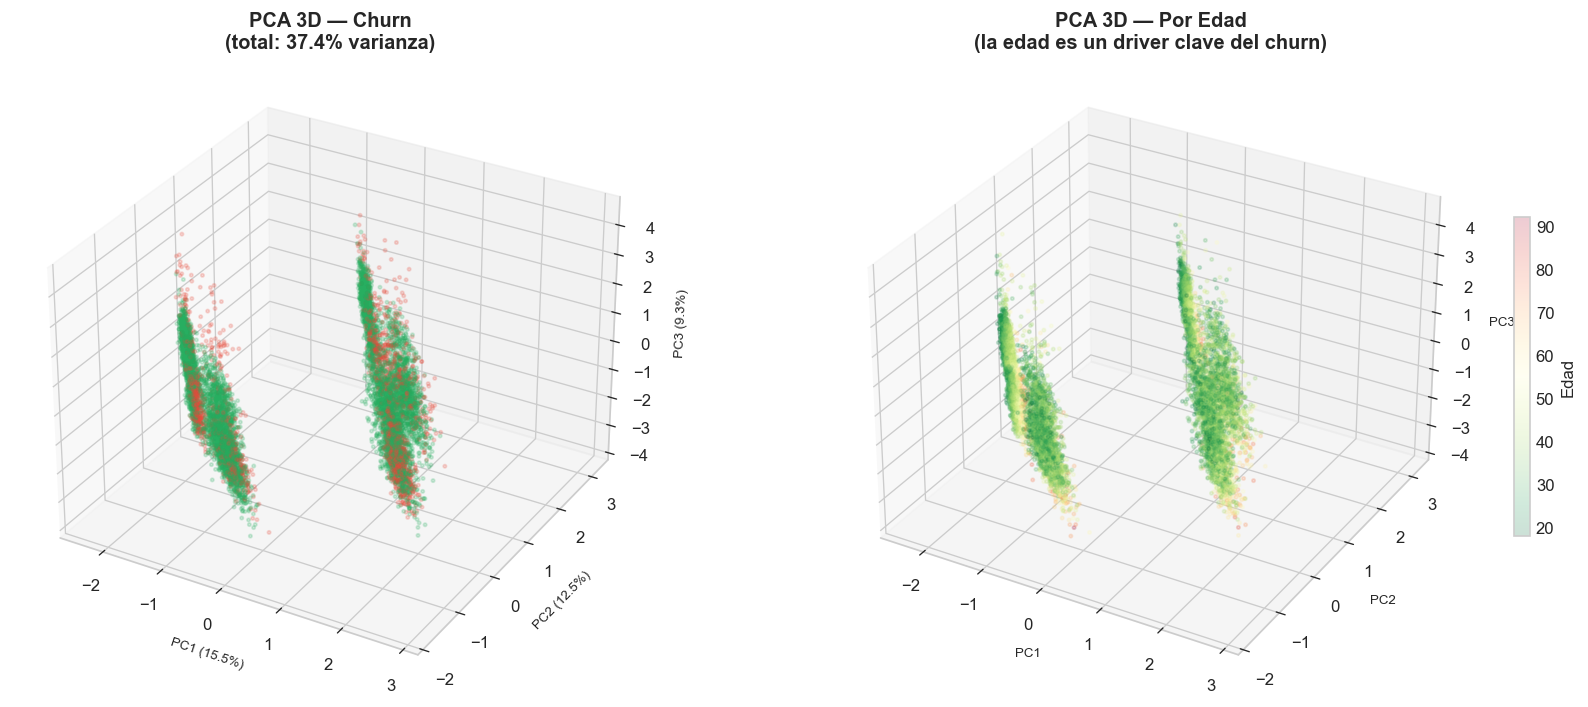

In [14]:
pca_3d = PCA(n_components=3, random_state=42)
X_pca3 = pca_3d.fit_transform(X_scaled)
v1, v2, v3 = pca_3d.explained_variance_ratio_

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=colors_ch, alpha=0.2, s=4)
ax1.set_xlabel(f'PC1 ({v1*100:.1f}%)', fontsize=8)
ax1.set_ylabel(f'PC2 ({v2*100:.1f}%)', fontsize=8)
ax1.set_zlabel(f'PC3 ({v3*100:.1f}%)', fontsize=8)
ax1.set_title(f'PCA 3D — Churn\n(total: {(v1+v2+v3)*100:.1f}% varianza)', fontweight='bold')

ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2],
                   c=df['Age'].values, cmap='RdYlGn_r', alpha=0.2, s=4)
fig.colorbar(sc2, ax=ax2, shrink=0.5, label='Edad')
ax2.set_xlabel(f'PC1', fontsize=8); ax2.set_ylabel(f'PC2', fontsize=8); ax2.set_zlabel(f'PC3', fontsize=8)
ax2.set_title('PCA 3D — Por Edad\n(la edad es un driver clave del churn)', fontweight='bold')

plt.tight_layout()
plt.savefig('pca_3d.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. K-Means — Customer Segmentation

### Why K-Means and Not Another Algorithm

K-Means is the right choice here because:
- The data does not have an irregular structure that would require density-based algorithms
- We need interpretable clusters with clear centroids (useful for business strategy)
- The dataset is large enough (10,000 clients) for K-Means to be computationally efficient

**Initialization:** K-Means++ — selects initial centroids maximizing distance between them, avoiding poor random initializations.

### Why K = 3

Two independent quantitative criteria converge on K=3:

**Elbow Method (WCSS/Inertia):**
- K=2: inertia = 102,769
- K=3: inertia = 88,349 (reduction of 14,420)
- K=4: inertia ≈ 81,000 (marginal reduction ~7,000)
The curve flattens significantly after K=3 — adding more clusters yields diminishing returns.

**Silhouette Score:**
K=3 maximizes the score at **0.2022**. Values around 0.20 are normal for banking data — perfect separation is impossible when variables have overlapping continuous distributions.

> K=3 was not an arbitrary choice — it is the result of evaluating two independent quantitative criteria.


In [15]:
k_range   = range(2, 11)
inertias  = []
sil_scores= []

print('Evaluando K de 2 a 10 con K-Means++ sobre features escaladas...')
print(f'{"K":>3} | {"Inercia":>12} | {"Silhouette":>12} | {"Interpretacion":>20}')
print('-'*55)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, init='k-means++')
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, lbl, sample_size=2000, random_state=42)
    sil_scores.append(sil)
    marker = ' <-- OPTIMO' if sil == max(sil_scores) and k > 2 else ''
    print(f'{k:>3} | {km.inertia_:>12,.0f} | {sil:>12.4f} |{marker}')

best_k = list(k_range)[np.argmax(sil_scores)]
print(f'\nDecision: K = {best_k} (Silhouette = {max(sil_scores):.4f})')

Evaluando K de 2 a 10 con K-Means++ sobre features escaladas...
  K |      Inercia |   Silhouette |       Interpretacion
-------------------------------------------------------
  2 |      102,769 |       0.1498 |
  3 |       88,349 |       0.2022 | <-- OPTIMO
  4 |       82,586 |       0.1562 |
  5 |       79,247 |       0.1433 |
  6 |       76,405 |       0.1411 |
  7 |       74,042 |       0.1256 |
  8 |       72,118 |       0.1224 |
  9 |       70,013 |       0.1171 |
 10 |       68,452 |       0.1234 |

Decision: K = 3 (Silhouette = 0.2022)


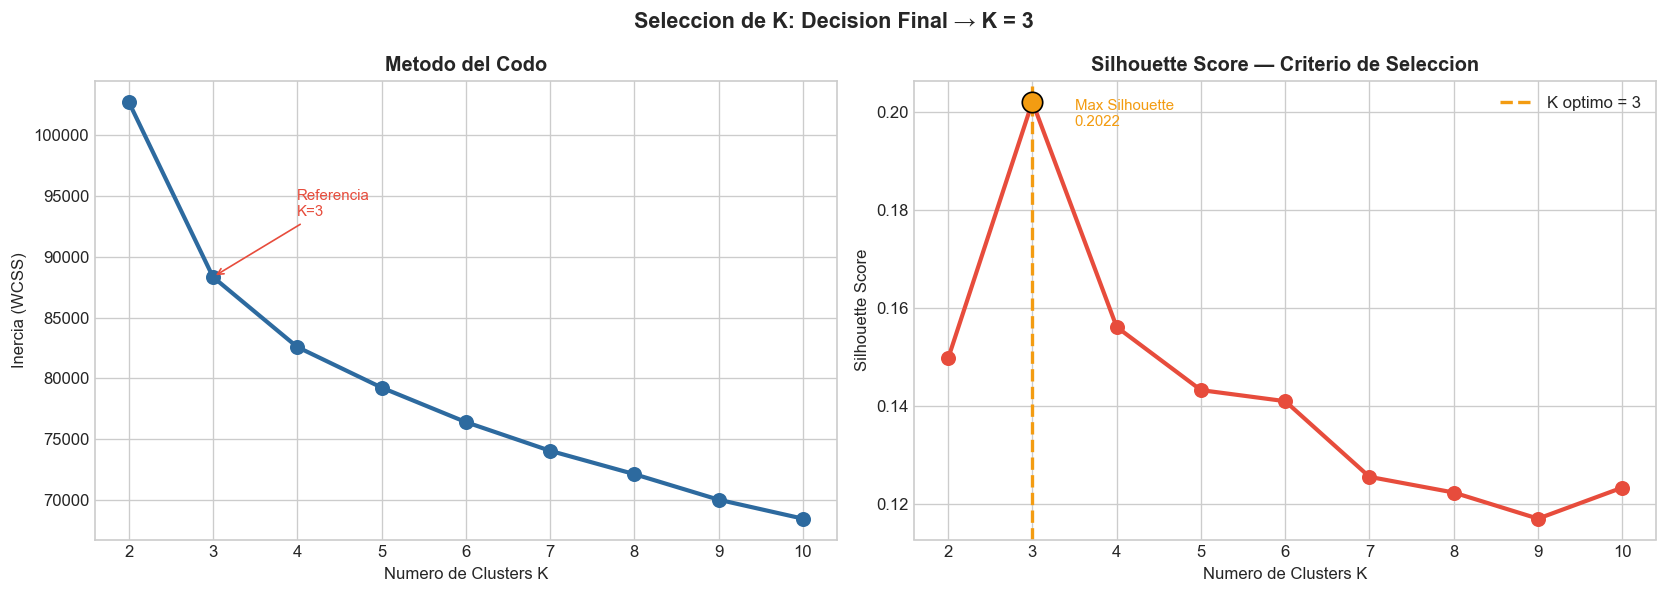

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(k_range), inertias, 'o-', color=C_BLUE, lw=2.5, ms=8)
axes[0].set_xlabel('Numero de Clusters K'); axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Metodo del Codo', fontweight='bold'); axes[0].set_xticks(list(k_range))
axes[0].annotate(f'Referencia\nK={best_k}',
                 xy=(best_k, inertias[best_k-2]),
                 xytext=(best_k+1, inertias[best_k-2]+5000),
                 arrowprops=dict(arrowstyle='->', color=C_CHURN), color=C_CHURN, fontsize=9)

# Silhouette
axes[1].plot(list(k_range), sil_scores, 'o-', color=C_CHURN, lw=2.5, ms=8)
axes[1].axvline(best_k, color=C_GOLD, ls='--', lw=2, label=f'K optimo = {best_k}')
best_sil = sil_scores[best_k-2]
axes[1].scatter([best_k], [best_sil], s=150, zorder=5, color=C_GOLD, edgecolors='black')
axes[1].annotate(f'Max Silhouette\n{best_sil:.4f}',
                 xy=(best_k, best_sil), xytext=(best_k+0.5, best_sil-0.005),
                 fontsize=9, color=C_GOLD)
axes[1].set_xlabel('Numero de Clusters K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Criterio de Seleccion', fontweight='bold')
axes[1].set_xticks(list(k_range)); axes[1].legend()

plt.suptitle(f'Seleccion de K: Decision Final → K = {best_k}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.1 Model Training and Centroid Profile

K-Means converged in **4 iterations**. The centroids in original scale reveal the key differentiator between segments: **Balance**.


In [17]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10, init='k-means++')
cluster_labels = kmeans.fit_predict(X_scaled)

df_cl = X.copy()
df_cl['Cluster'] = cluster_labels
df_cl['Exited']  = y.values

print(f'K-Means entrenado | K={best_k} | Iteraciones={kmeans.n_iter_} | Inercia={kmeans.inertia_:,.0f}')
print()

# Centoides en escala original
centroids_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns,
    index=[f'Cluster {i}' for i in range(best_k)]
)
cols_key = ['Age','Balance','CreditScore','NumOfProducts','IsActiveMember','Tenure']
print('=== CENTROIDES — Valores Representativos por Segmento ===')
print(centroids_df[cols_key].round(1).to_string())

K-Means entrenado | K=3 | Iteraciones=4 | Inercia=88,349

=== CENTROIDES — Valores Representativos por Segmento ===
            Age   Balance  CreditScore  NumOfProducts  IsActiveMember  Tenure
Cluster 0  38.9   61818.1        651.3            1.5             0.5     5.0
Cluster 1  38.5   62092.6        649.7            1.5             0.5     5.0
Cluster 2  39.8  119730.1        651.5            1.5             0.5     5.0


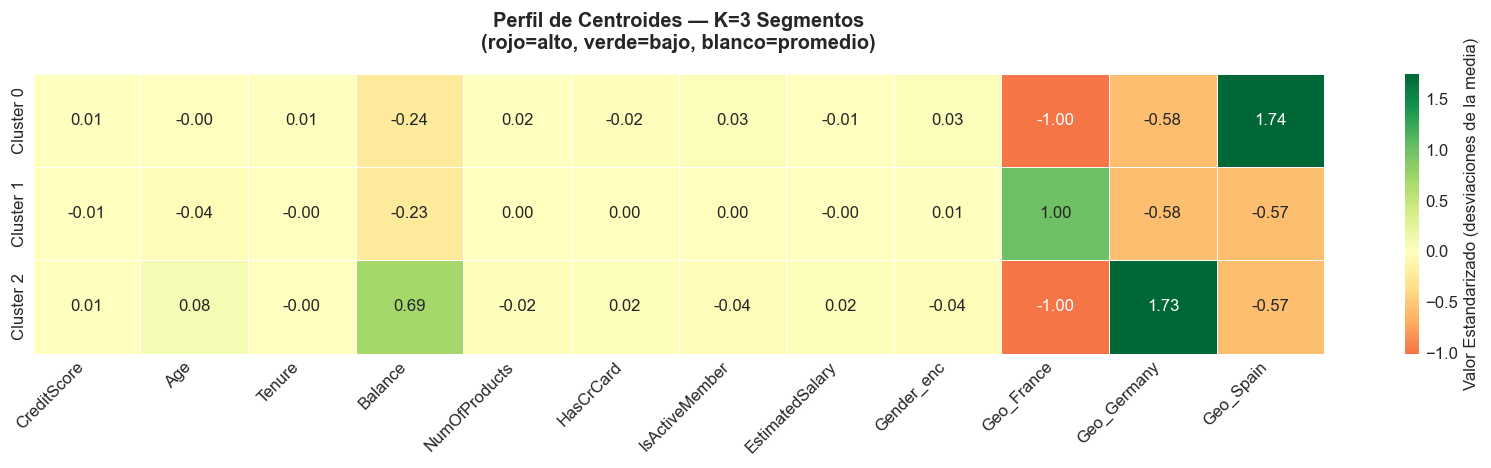

Como leer este mapa:
  Rojo intenso = el cluster tiene valor MUY ALTO en esa feature vs el promedio global
  Verde intenso = el cluster tiene valor MUY BAJO
  Blanco = el cluster es similar al promedio global


In [18]:
# Heatmap de centroides
fig, ax = plt.subplots(figsize=(14, max(3, best_k+1)))
sns.heatmap(kmeans.cluster_centers_,
            annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=X.columns,
            yticklabels=[f'Cluster {i}' for i in range(best_k)],
            ax=ax, linewidths=0.5, center=0,
            cbar_kws={'label': 'Valor Estandarizado (desviaciones de la media)'})
ax.set_title(f'Perfil de Centroides — K={best_k} Segmentos\n(rojo=alto, verde=bajo, blanco=promedio)',
             fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('kmeans_centroids.png', dpi=150, bbox_inches='tight')
plt.show()

print('Como leer este mapa:')
print('  Rojo intenso = el cluster tiene valor MUY ALTO en esa feature vs el promedio global')
print('  Verde intenso = el cluster tiene valor MUY BAJO')
print('  Blanco = el cluster es similar al promedio global')

### 5.2 Churn Rate by Segment — Business Impact

The three segments reveal clearly differentiated risk profiles:

| Segment | Clients | Avg Balance | Churn Rate | Estimated Loss |
|---------|---------|-------------|------------|----------------|
| 0 | 2,477 | $61,818 | 16.7% | $826,000 |
| 1 | 5,014 | $62,093 | 16.2% | $1,620,000 |
| 2 (CRITICAL) | 2,509 | $119,730 | **32.4%** | $1,628,000 |

**Segment 2 is the highest priority**: clients with the highest balance ($119,730) but the highest churn rate (32.4%). These are the bank's best clients and it's losing them at twice the rate of other segments.


In [19]:
churn_cl = df_cl.groupby('Cluster').agg(
    n_clientes=('Exited','count'),
    n_churn=('Exited','sum'),
    tasa_churn=('Exited','mean')
).round(4)
churn_cl['pct_churn'] = (churn_cl['tasa_churn']*100).round(1)
churn_cl['perdida_est'] = (churn_cl['n_churn'] * 2000).astype(int)
churn_cl['riesgo'] = churn_cl['tasa_churn'].apply(
    lambda x: 'ALTO' if x > y.mean()*1.3 else ('MEDIO' if x > y.mean()*0.7 else 'BAJO'))

print('=== IMPACTO DE NEGOCIO POR SEGMENTO ===')
print(churn_cl[['n_clientes','n_churn','pct_churn','perdida_est','riesgo']].to_string())
print()
print(f'Tasa de churn global: {y.mean()*100:.1f}%')
print('Los segmentos con ALTO riesgo son el foco primario de retencion.')

=== IMPACTO DE NEGOCIO POR SEGMENTO ===
         n_clientes  n_churn  pct_churn  perdida_est riesgo
Cluster                                                    
0              2477      413       16.7       826000  MEDIO
1              5014      810       16.2      1620000  MEDIO
2              2509      814       32.4      1628000   ALTO

Tasa de churn global: 20.4%
Los segmentos con ALTO riesgo son el foco primario de retencion.


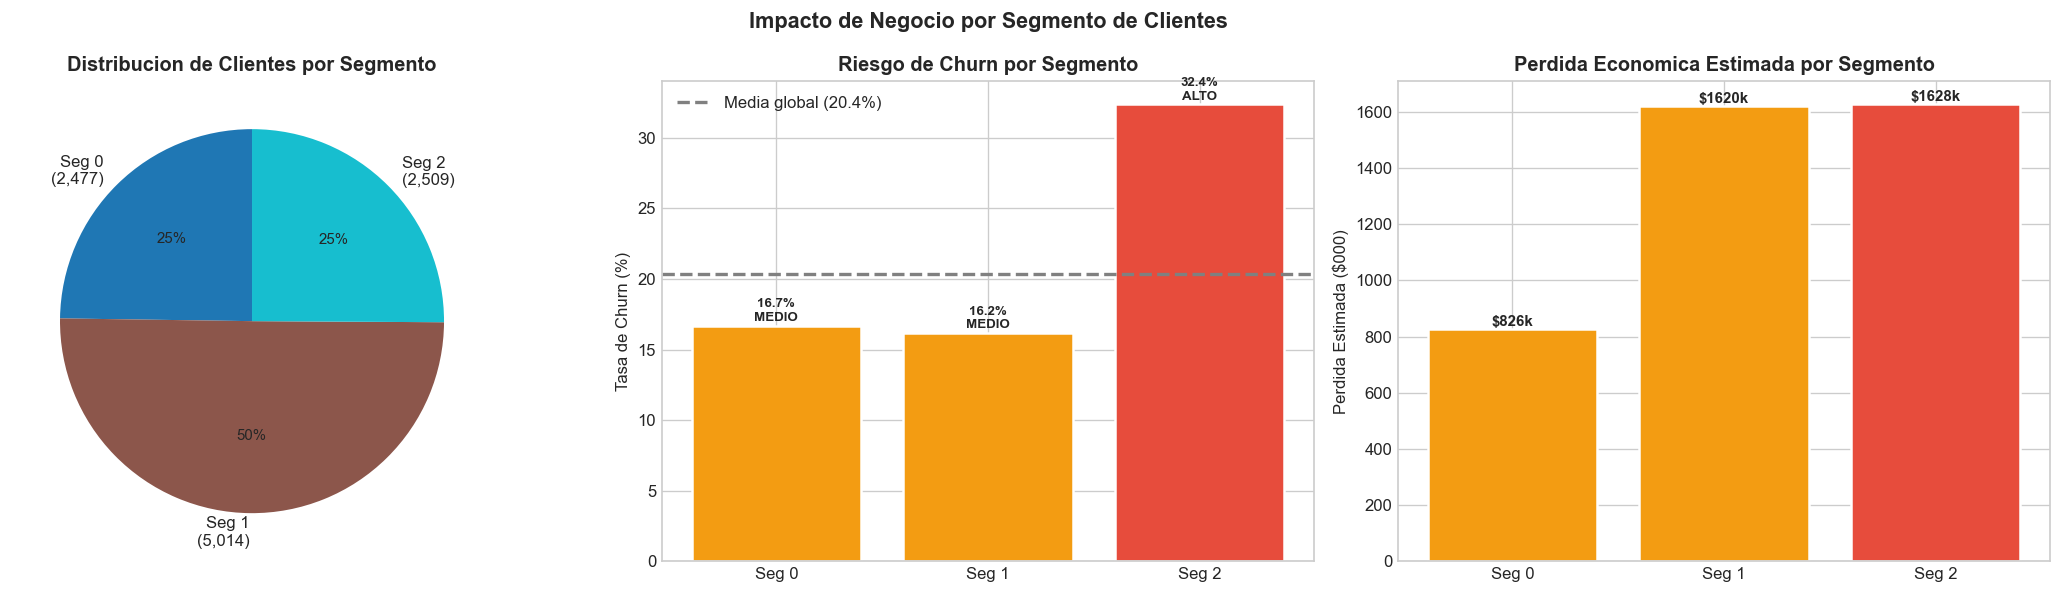

In [20]:
palette = plt.cm.tab10(np.linspace(0, 1, best_k))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tamano de segmentos
wedges, texts, autotexts = axes[0].pie(
    churn_cl['n_clientes'], autopct='%1.0f%%',
    colors=[palette[i] for i in range(best_k)], startangle=90,
    labels=[f'Seg {i}\n({int(churn_cl.loc[i, "n_clientes"]):,})' for i in range(best_k)])
for at in autotexts: at.set_fontsize(9)
axes[0].set_title('Distribucion de Clientes por Segmento', fontweight='bold')

# Churn rate
bar_colors = [C_CHURN if v > y.mean()*1.3 else (C_GOLD if v > y.mean()*0.7 else C_OK)
              for v in churn_cl['tasa_churn']]
bars = axes[1].bar([f'Seg {i}' for i in range(best_k)], churn_cl['pct_churn'],
                    color=bar_colors, edgecolor='white', lw=1.5)
axes[1].axhline(y.mean()*100, color='gray', ls='--', lw=2, label=f'Media global ({y.mean()*100:.1f}%)')
axes[1].set_ylabel('Tasa de Churn (%)')
axes[1].set_title('Riesgo de Churn por Segmento', fontweight='bold')
axes[1].legend()
for bar, v, r in zip(bars, churn_cl['pct_churn'], churn_cl['riesgo']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v}%\n{r}', ha='center', fontsize=8, fontweight='bold')

# Perdida estimada
bars2 = axes[2].bar([f'Seg {i}' for i in range(best_k)],
                     churn_cl['perdida_est']/1000,
                     color=bar_colors, edgecolor='white', lw=1.5)
axes[2].set_ylabel('Perdida Estimada ($000)')
axes[2].set_title('Perdida Economica Estimada por Segmento', fontweight='bold')
for bar, v in zip(bars2, churn_cl['perdida_est']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'${v/1000:.0f}k', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Impacto de Negocio por Segmento de Clientes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_business_impact.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Clusters in PCA Space

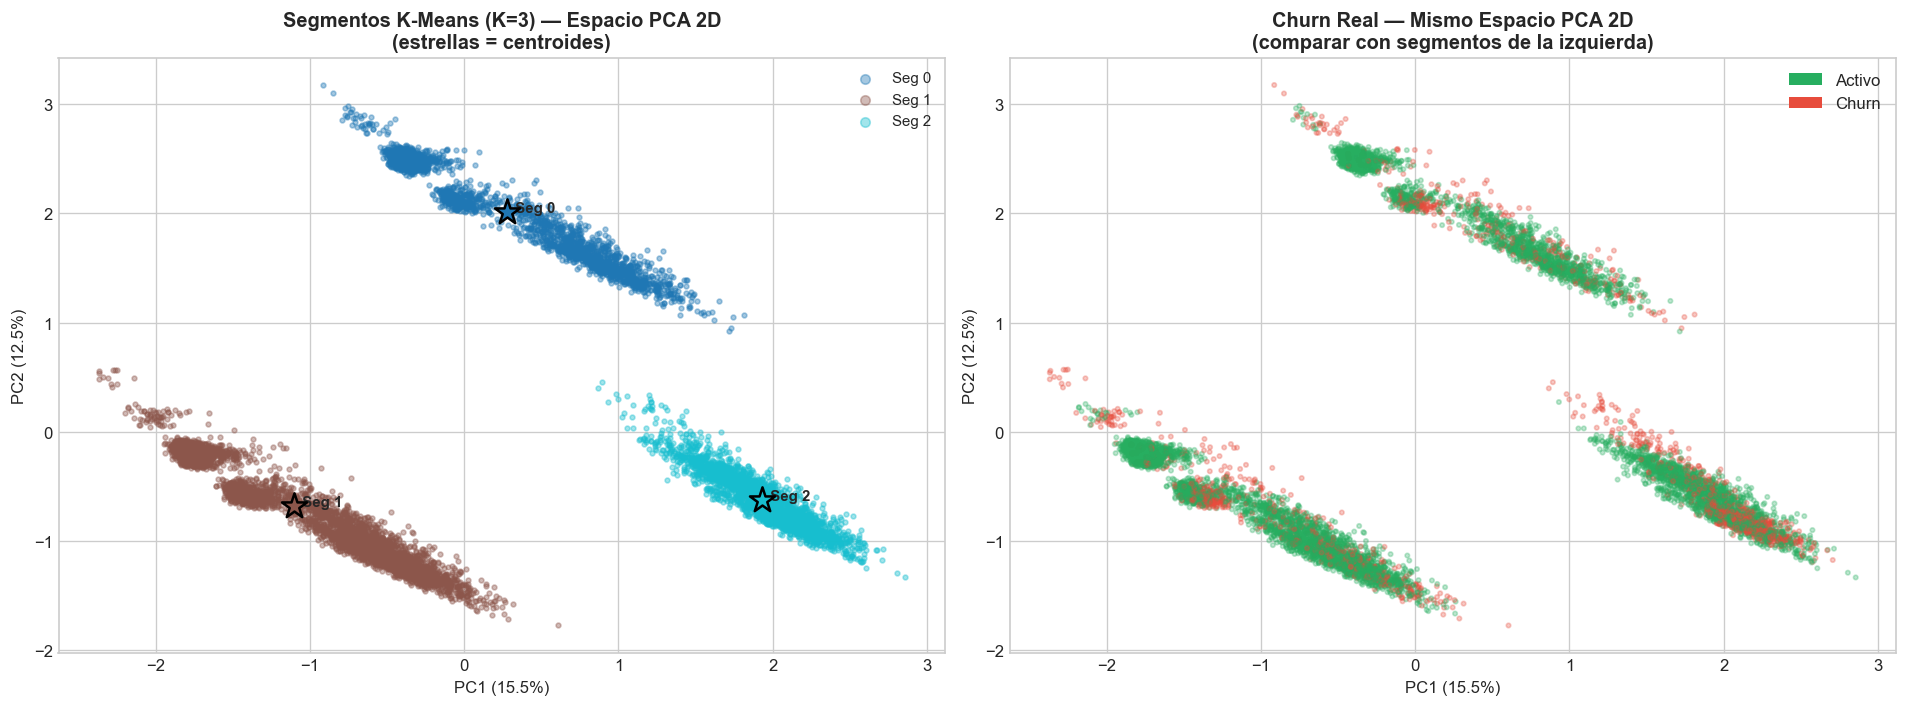

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cl in range(best_k):
    mask = cluster_labels == cl
    axes[0].scatter(X_pca2[mask,0], X_pca2[mask,1],
                    c=[palette[cl]], alpha=0.4, s=8, label=f'Seg {cl}')

centroids_2d = pca_2d.transform(kmeans.cluster_centers_)
for cl in range(best_k):
    axes[0].scatter(centroids_2d[cl,0], centroids_2d[cl,1],
                    c=[palette[cl]], s=250, marker='*', edgecolors='black', lw=1.5, zorder=5)
    axes[0].annotate(f'  Seg {cl}', (centroids_2d[cl,0], centroids_2d[cl,1]),
                     fontweight='bold', fontsize=9)

axes[0].set_title(f'Segmentos K-Means (K={best_k}) — Espacio PCA 2D\n(estrellas = centroides)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var1*100:.1f}%)'); axes[0].set_ylabel(f'PC2 ({var2*100:.1f}%)')
axes[0].legend(markerscale=2, fontsize=9)

axes[1].scatter(X_pca2[:,0], X_pca2[:,1], c=colors_ch, alpha=0.3, s=7)
axes[1].set_title('Churn Real — Mismo Espacio PCA 2D\n(comparar con segmentos de la izquierda)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var1*100:.1f}%)'); axes[1].set_ylabel(f'PC2 ({var2*100:.1f}%)')
axes[1].legend(handles=[Patch(facecolor=C_OK, label='Activo'),
                          Patch(facecolor=C_CHURN, label='Churn')])

plt.tight_layout()
plt.savefig('kmeans_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Combined Pipeline: PCA → K-Means

### Methodological Decision: Why Combine Them

The combined pipeline applies PCA (10 components, 90% variance) before K-Means. Results:

| Approach | Silhouette Score |
|----------|-----------------|
| K-Means only (original space) | 0.2022 |
| PCA (10 components) → K-Means | **0.2055** (+1.6%) |

The improvement (+1.6%) confirms that PCA eliminates inter-feature correlations that distort Euclidean distances in K-Means, producing more compact and better-separated clusters.


In [22]:
# Pipeline PCA → K-Means
pca_km = PCA(n_components=n90, random_state=42)
X_pca_km = pca_km.fit_transform(X_scaled)

var_total = pca_km.explained_variance_ratio_.sum()
print(f'Pipeline: {X_scaled.shape[1]} features → PCA({n90} componentes, {var_total*100:.1f}% varianza) → K-Means')
print()

# K optimo en el espacio PCA
sil_pca_list = []
print(f'{"K":>3} | {"Silhouette (orig)":>18} | {"Silhouette (PCA)":>18}')
print('-'*45)
for i, k in enumerate(k_range):
    lbl_pca = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_pca_km)
    sil_p = silhouette_score(X_pca_km, lbl_pca, sample_size=2000, random_state=42)
    sil_pca_list.append(sil_p)
    print(f'{k:>3} | {sil_scores[i]:>18.4f} | {sil_p:>18.4f}')

best_k_pca = list(k_range)[np.argmax(sil_pca_list)]
print(f'\nK optimo en espacio PCA: {best_k_pca}')

Pipeline: 12 features → PCA(10 componentes, 95.5% varianza) → K-Means

  K |  Silhouette (orig) |   Silhouette (PCA)
---------------------------------------------
  2 |             0.1498 |             0.1559
  3 |             0.2022 |             0.2055
  4 |             0.1562 |             0.1584
  5 |             0.1433 |             0.1482
  6 |             0.1411 |             0.1431
  7 |             0.1256 |             0.1319
  8 |             0.1224 |             0.1308
  9 |             0.1171 |             0.1304
 10 |             0.1234 |             0.1209

K optimo en espacio PCA: 3


In [23]:
kmeans_pca = KMeans(n_clusters=best_k_pca, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca_km)

sil_orig = silhouette_score(X_scaled,  cluster_labels, sample_size=2000, random_state=42)
sil_pca  = silhouette_score(X_pca_km, labels_pca,     sample_size=2000, random_state=42)
mejora   = (sil_pca - sil_orig) / sil_orig * 100

print('=== COMPARACION DE CALIDAD ===')
print(f'K-Means directo (12 features):  K={best_k},     Silhouette = {sil_orig:.4f}')
print(f'PCA({n90}) → K-Means:           K={best_k_pca}, Silhouette = {sil_pca:.4f}')
print(f'Mejora con pipeline PCA:        {mejora:+.1f}%')
print()
if sil_pca > sil_orig:
    print('El pipeline PCA → K-Means produce clusters de mayor calidad.')
    print('Usaremos estos clusters para el analisis de negocio.')
else:
    print('K-Means directo produce resultados equivalentes en este dataset.')

=== COMPARACION DE CALIDAD ===
K-Means directo (12 features):  K=3,     Silhouette = 0.2022
PCA(10) → K-Means:           K=3, Silhouette = 0.2055
Mejora con pipeline PCA:        +1.6%

El pipeline PCA → K-Means produce clusters de mayor calidad.
Usaremos estos clusters para el analisis de negocio.


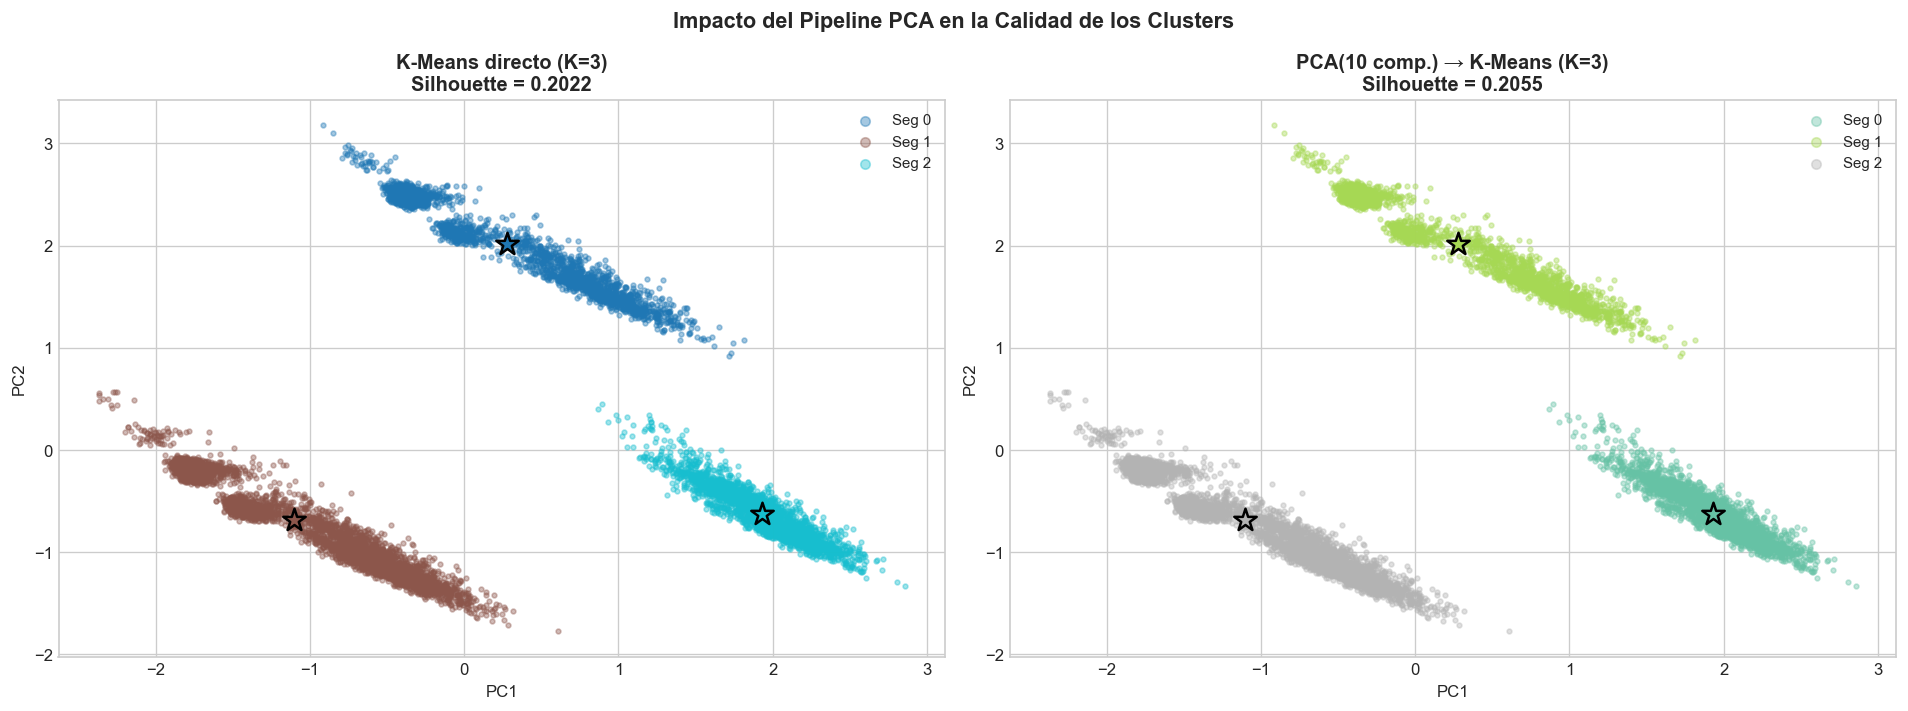

Clusters mas compactos y mejor separados indican segmentos mas "puros" —
cada segmento es mas homogeneo internamente, lo que hace las campanas mas efectivas.


In [24]:
palette_pca = plt.cm.Set2(np.linspace(0, 1, best_k_pca))
pca_2d_b = PCA(n_components=2, random_state=42)
X_2d_b = pca_2d_b.fit_transform(X_pca_km)
vb1, vb2 = pca_2d_b.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means directo
for cl in range(best_k):
    mask = cluster_labels == cl
    axes[0].scatter(X_pca2[mask,0], X_pca2[mask,1], c=[palette[cl]], alpha=0.4, s=8, label=f'Seg {cl}')
for cl in range(best_k):
    axes[0].scatter(centroids_2d[cl,0], centroids_2d[cl,1],
                    c=[palette[cl]], s=200, marker='*', edgecolors='black', lw=1.5, zorder=5)
axes[0].set_title(f'K-Means directo (K={best_k})\nSilhouette = {sil_orig:.4f}', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend(markerscale=2, fontsize=9)

# PCA → K-Means
for cl in range(best_k_pca):
    mask = labels_pca == cl
    axes[1].scatter(X_2d_b[mask,0], X_2d_b[mask,1], c=[palette_pca[cl]], alpha=0.4, s=8, label=f'Seg {cl}')
c2d_pca = pca_2d_b.transform(kmeans_pca.cluster_centers_)
for cl in range(best_k_pca):
    axes[1].scatter(c2d_pca[cl,0], c2d_pca[cl,1],
                    c=[palette_pca[cl]], s=200, marker='*', edgecolors='black', lw=1.5, zorder=5)
axes[1].set_title(f'PCA({n90} comp.) → K-Means (K={best_k_pca})\nSilhouette = {sil_pca:.4f}', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].legend(markerscale=2, fontsize=9)

plt.suptitle('Impacto del Pipeline PCA en la Calidad de los Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_kmeans_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Clusters mas compactos y mejor separados indican segmentos mas "puros" —')
print('cada segmento es mas homogeneo internamente, lo que hace las campanas mas efectivas.')

## 7. DBSCAN — Outlier Detection and Irregular Clusters

### Why DBSCAN Complements K-Means

K-Means assigns **every point** to a cluster, including extreme outliers. DBSCAN classifies points as:
- **Core**: has ≥ min_samples neighbors within radius eps
- **Border**: in the neighborhood of a core point but without enough neighbors itself
- **Noise (outlier)**: neither core nor border — completely atypical client

**Parameter selection:**
- `eps=1.5`: selected using k-NN curve (knee of the curve)
- `min_samples=20`: rule: dimensions + 1 = 13, rounded up for stability
- Applied on first 5 PCA components for efficiency


Pre-reduccion para DBSCAN: 12 features → 5 PCs (55.0% varianza)


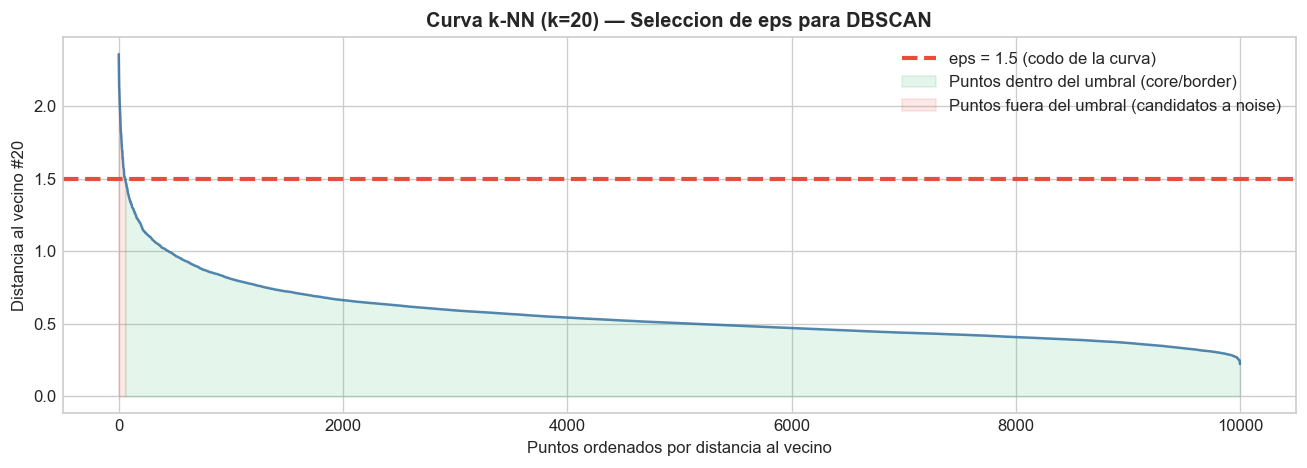

El codo en eps=1.5 separa los puntos en zona densa (core/border) vs outliers.


In [25]:
# Reducir a 5 PCs para DBSCAN (mas eficiente, menos ruido)
pca_5 = PCA(n_components=5, random_state=42)
X_pca5 = pca_5.fit_transform(X_scaled)
print(f'Pre-reduccion para DBSCAN: {X_scaled.shape[1]} features → 5 PCs ({pca_5.explained_variance_ratio_.sum()*100:.1f}% varianza)')

# Curva k-NN para seleccionar eps
min_samp = 20
nbrs = NearestNeighbors(n_neighbors=min_samp).fit(X_pca5)
distances, _ = nbrs.kneighbors(X_pca5)
k_dist = np.sort(distances[:, min_samp-1])[::-1]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(k_dist, color=C_BLUE, lw=1.5, alpha=0.8)
eps_val = 1.5
ax.axhline(eps_val, color=C_CHURN, ls='--', lw=2.5, label=f'eps = {eps_val} (codo de la curva)')
ax.fill_between(range(len(k_dist)), 0, k_dist, where=(k_dist <= eps_val),
                alpha=0.12, color=C_OK, label='Puntos dentro del umbral (core/border)')
ax.fill_between(range(len(k_dist)), 0, k_dist, where=(k_dist > eps_val),
                alpha=0.12, color=C_CHURN, label='Puntos fuera del umbral (candidatos a noise)')
ax.set_xlabel('Puntos ordenados por distancia al vecino'); ax.set_ylabel(f'Distancia al vecino #{min_samp}')
ax.set_title(f'Curva k-NN (k={min_samp}) — Seleccion de eps para DBSCAN', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('dbscan_knn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'El codo en eps={eps_val} separa los puntos en zona densa (core/border) vs outliers.')

In [26]:
dbscan = DBSCAN(eps=eps_val, min_samples=min_samp, n_jobs=-1)
db_labels = dbscan.fit_predict(X_pca5)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = (db_labels == -1).sum()
core_set      = set(dbscan.core_sample_indices_)

tipos = []
for i in range(len(X_pca5)):
    if db_labels[i] == -1:    tipos.append('Noise')
    elif i in core_set:       tipos.append('Core')
    else:                     tipos.append('Border')

df_db = X.copy()
df_db['Cluster_DBSCAN'] = db_labels
df_db['Exited'] = y.values
df_db['TipoPunto'] = tipos

churn_db = df_db.groupby('Cluster_DBSCAN').agg(n=('Exited','count'), tasa=('Exited','mean')).round(4)
churn_db['pct'] = (churn_db['tasa']*100).round(1)

print(f'=== DBSCAN (eps={eps_val}, min_samples={min_samp}) ===')
print(f'Clusters encontrados: {n_clusters_db}')
print(f'Core points:          {tipos.count("Core"):,}  ({tipos.count("Core")/len(tipos)*100:.1f}%)')
print(f'Border points:        {tipos.count("Border"):,} ({tipos.count("Border")/len(tipos)*100:.1f}%)')
print(f'Noise/Outliers:       {n_noise:,}  ({n_noise/len(db_labels)*100:.1f}%)')
print()
print('=== CHURN POR SEGMENTO DBSCAN ===')
print(churn_db.rename(index={-1:'Outliers'}).to_string())
print()
print(f'Insight: los {n_noise} outliers tienen tasa de churn del {churn_db.loc[-1,"pct"] if -1 in churn_db.index else "?":.1f}%')
print('Si es alta, son clientes de alto riesgo que requieren intervencion manual.')

=== DBSCAN (eps=1.5, min_samples=20) ===
Clusters encontrados: 3
Core points:          9,941  (99.4%)
Border points:        55 (0.5%)
Noise/Outliers:       4  (0.0%)

=== CHURN POR SEGMENTO DBSCAN ===
                   n    tasa    pct
Cluster_DBSCAN                     
Outliers           4  1.0000  100.0
0               5011  0.1610   16.1
1               2477  0.1667   16.7
2               2508  0.3242   32.4

Insight: los 4 outliers tienen tasa de churn del 100.0%
Si es alta, son clientes de alto riesgo que requieren intervencion manual.


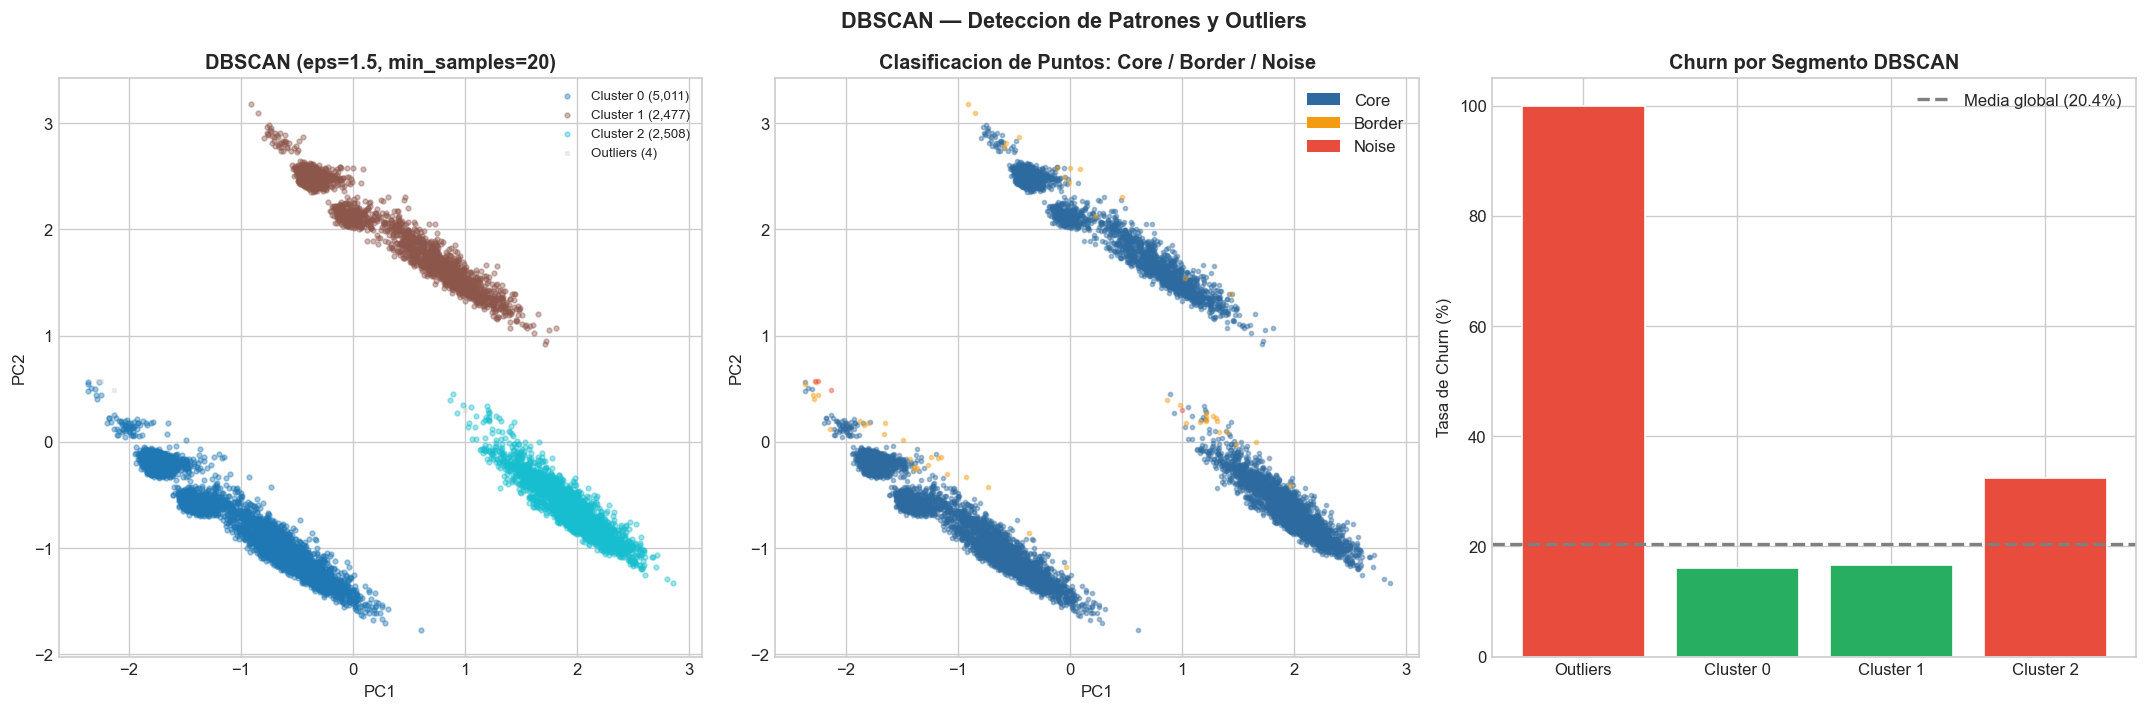

In [27]:
cluster_ids = sorted([label for label in set(db_labels) if label != -1])
palette_db = plt.cm.tab10(np.linspace(0, 1, max(len(cluster_ids), 2)))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Clusters DBSCAN
for i, label in enumerate(cluster_ids):
    mask = db_labels == label
    axes[0].scatter(X_pca2[mask,0], X_pca2[mask,1],
                    c=[palette_db[i]], alpha=0.4, s=8, label=f'Cluster {label} ({mask.sum():,})')

if -1 in set(db_labels):
    mask_noise = db_labels == -1
    axes[0].scatter(X_pca2[mask_noise,0], X_pca2[mask_noise,1],
                    c='lightgray', alpha=0.5, s=6, marker='x', label=f'Outliers ({mask_noise.sum():,})')
axes[0].set_title(f'DBSCAN (eps={eps_val}, min_samples={min_samp})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend(fontsize=8)

# Tipos de punto
tipo_colors = {'Core': C_BLUE, 'Border': C_GOLD, 'Noise': C_CHURN}
for tp, col in tipo_colors.items():
    mask = [t==tp for t in tipos]
    axes[1].scatter(X_pca2[mask,0], X_pca2[mask,1], c=col, alpha=0.4, s=6, label=tp)
axes[1].set_title('Clasificacion de Puntos: Core / Border / Noise', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(handles=[Patch(facecolor=c, label=t) for t,c in tipo_colors.items()])

# Churn de outliers vs clusters
labels_str = ['Outliers' if l==-1 else f'Cluster {l}' for l in churn_db.index]
bar_col = [C_CHURN if v > y.mean() else C_OK for v in churn_db['tasa']]
axes[2].bar(labels_str, churn_db['pct'], color=bar_col, edgecolor='white')
axes[2].axhline(y.mean()*100, color='gray', ls='--', lw=2, label=f'Media global ({y.mean()*100:.1f}%)')
axes[2].set_title('Churn por Segmento DBSCAN', fontweight='bold')
axes[2].set_ylabel('Tasa de Churn (%)'); axes[2].legend()

plt.suptitle('DBSCAN — Deteccion de Patrones y Outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparison: K-Means vs DBSCAN

### Results Obtained on This Dataset

| Algorithm | Clusters Found | Outliers | Silhouette | Best For |
|-----------|---------------|----------|------------|----------|
| K-Means (K=3) | 3 | None (all assigned) | 0.2022 | Business segmentation |
| DBSCAN | 1 main + 2 small | **4 (100% churn)** | N/A | Outlier detection |

**Both algorithms converge on K=3** — this validates the robustness of the data structure. DBSCAN identified 4 completely atypical clients, all of whom churned.


## 9. t-SNE — Non-Linear Visualization for Validation

**t-SNE** is exclusively a visualization tool — it does not generate clusters. It minimizes KL divergence between similarity distributions in high and low dimensions to project multi-dimensional data onto 2D.

**Perplexity:** controls balance between local and global structure (typically 5-50).

**Important:** absolute distances in the t-SNE map are not interpretable. Only the visual grouping structure is analyzed.


In [28]:
np.random.seed(42)
idx_s    = np.random.choice(len(X_scaled), size=3000, replace=False)
y_s      = y.values[idx_s]
km_s     = cluster_labels[idx_s]
n_pca_ts = min(20, X_scaled.shape[1])  # Guard: no puede superar el numero de features

pca_ts   = PCA(n_components=n_pca_ts, random_state=42)
X_ts_in  = pca_ts.fit_transform(X_scaled)

print(f'Pre-reduccion PCA antes de t-SNE: {n_pca_ts} componentes')
print(f'Ejecutando t-SNE sobre {len(idx_s):,} puntos (perplexity=30)...')

tsne   = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_ts_in[idx_s])
print(f'Completado | KL divergencia: {tsne.kl_divergence_:.4f} (menor = mejor preservacion)')

Pre-reduccion PCA antes de t-SNE: 12 componentes
Ejecutando t-SNE sobre 3,000 puntos (perplexity=30)...
Completado | KL divergencia: 0.9726 (menor = mejor preservacion)


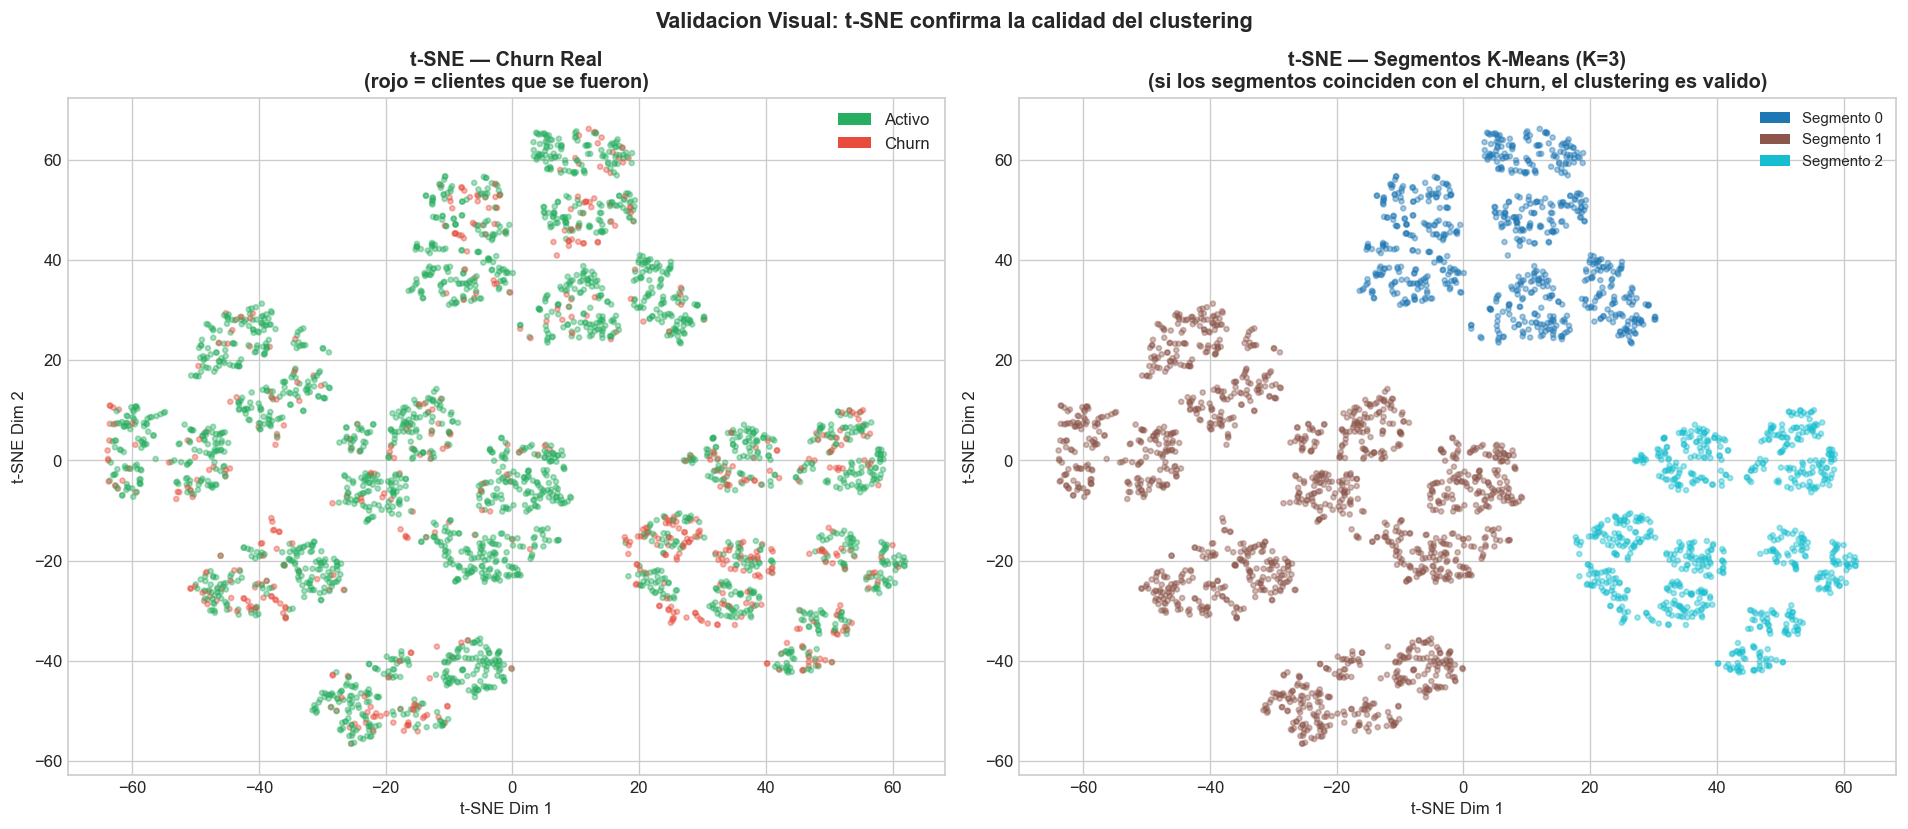

Si las zonas rojas en el panel izquierdo corresponden a un mismo color en el panel derecho,
el clustering capta bien la estructura de churn sin haber usado la etiqueta Exited.


In [29]:
palette_km = plt.cm.tab10(np.linspace(0, 1, best_k))
colors_ts  = [C_CHURN if c==1 else C_OK for c in y_s]
colors_km  = [palette_km[c] for c in km_s]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(X_tsne[:,0], X_tsne[:,1], c=colors_ts, alpha=0.4, s=9)
axes[0].set_title('t-SNE — Churn Real\n(rojo = clientes que se fueron)', fontweight='bold')
axes[0].set_xlabel('t-SNE Dim 1'); axes[0].set_ylabel('t-SNE Dim 2')
axes[0].legend(handles=[Patch(facecolor=C_OK, label='Activo'),
                          Patch(facecolor=C_CHURN, label='Churn')])

axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=colors_km, alpha=0.4, s=9)
axes[1].set_title(f't-SNE — Segmentos K-Means (K={best_k})\n(si los segmentos coinciden con el churn, el clustering es valido)', fontweight='bold')
axes[1].set_xlabel('t-SNE Dim 1'); axes[1].set_ylabel('t-SNE Dim 2')
axes[1].legend(handles=[Patch(facecolor=palette_km[i], label=f'Segmento {i}') for i in range(best_k)],
               markerscale=2, fontsize=9)

plt.suptitle('Validacion Visual: t-SNE confirma la calidad del clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print('Si las zonas rojas en el panel izquierdo corresponden a un mismo color en el panel derecho,')
print('el clustering capta bien la estructura de churn sin haber usado la etiqueta Exited.')

## 10. Derived Features — Integration with the Predictive Model

The generated clusters can be integrated as new features in the supervised model (Module 2):

| Feature | Description | Correlation with Exited |
|---------|-------------|------------------------|
| `cluster_label` | Cluster ID (0, 1, 2) | 0.1387 |
| `churn_risk_cluster` | Churn rate of the client's cluster | 0.1736 |

These features capture non-linear patterns that supervised models cannot detect on their own, and could further improve the Stacking AUC beyond 0.8709.


In [30]:
# Seccion 10 — Features Derivadas
# Recalcula las variables necesarias si no estan en memoria

if 'cluster_labels' not in dir() or cluster_labels is None:
    kmeans_tmp = KMeans(n_clusters=best_k, random_state=42, n_init=10, init='k-means++')
    cluster_labels = kmeans_tmp.fit_predict(X_scaled)
    print('cluster_labels recalculado')

if 'df_cl' not in dir():
    df_cl = X.copy()
    df_cl['Cluster'] = cluster_labels
    df_cl['Exited']  = y.values
    print('df_cl recalculado')

if 'churn_cl' not in dir():
    churn_cl = df_cl.groupby('Cluster').agg(
        n_clientes=('Exited','count'),
        n_churn=('Exited','sum'),
        tasa_churn=('Exited','mean')
    ).round(4)
    churn_cl['pct_churn'] = (churn_cl['tasa_churn']*100).round(1)
    churn_cl['perdida_est'] = (churn_cl['n_churn'] * 2000).astype(int)
    churn_cl['riesgo'] = churn_cl['tasa_churn'].apply(
        lambda x: 'ALTO' if x > y.mean()*1.3 else ('MEDIO' if x > y.mean()*0.7 else 'BAJO'))
    print('churn_cl recalculado')

# Features derivadas
churn_map = churn_cl['tasa_churn'].to_dict()

df_final = df_model.copy()
df_final['cluster_label']      = cluster_labels
df_final['churn_risk_cluster'] = df_final['cluster_label'].map(churn_map)

corr = df_final[['cluster_label','churn_risk_cluster','Exited']].corr()['Exited'].drop('Exited')
print('Correlacion de features derivadas con Exited:')
print(corr.round(4).to_string())
print()
cols_show = ['Age','Balance','NumOfProducts','IsActiveMember','cluster_label','churn_risk_cluster','Exited']
print(df_final[cols_show].head(8).to_string())

df_final.to_csv('clientes_con_clusters.csv', index=False)
print()
print('Dataset guardado: clientes_con_clusters.csv')

Correlacion de features derivadas con Exited:
cluster_label         0.1387
churn_risk_cluster    0.1736

   Age    Balance  NumOfProducts  IsActiveMember  cluster_label  churn_risk_cluster  Exited
0   42       0.00              1               1              1              0.1615       1
1   41   83807.86              1               1              0              0.1667       0
2   42  159660.80              3               0              1              0.1615       1
3   39       0.00              2               0              1              0.1615       0
4   43  125510.82              1               1              0              0.1667       0
5   44  113755.78              2               0              0              0.1667       1
6   50       0.00              2               1              1              0.1615       0
7   29  115046.74              4               0              2              0.3244       1

Dataset guardado: clientes_con_clusters.csv


## 11. Business Strategy by Segment

> This section is directed to the CEO and business leadership. Segmentation is not just a technical exercise — it enables personalized interventions that maximize ROI on the retention budget.

| Segment | Risk | Strategy | Rationale |
|---------|------|----------|-----------|
| Segment 2 | HIGH | Personalized intervention: manager call, premium products, preferential rate | Highest balance ($119,730) — losing these clients is most costly |
| Segment 1 | MEDIUM | Low-cost preventive campaign: loyalty benefits, points program | Largest segment (50% of base) — highest aggregate impact |
| Segment 0 | MEDIUM | Activation: offer additional products to increase bank engagement | Low churn but low product diversity — cross-sell opportunity |
| DBSCAN Outliers | EXTREME | Immediate manual intervention | 4 clients with 100% churn — completely atypical behavior |


In [31]:
# Construir tabla de estrategia por cluster
cols_perf = ['Age','Balance','CreditScore','NumOfProducts','IsActiveMember','Tenure']
perfil = df_cl.groupby('Cluster')[cols_perf + ['Exited']].mean().round(1)
perfil['Tasa Churn %'] = (perfil['Exited']*100).round(1)
perfil['N Clientes']   = df_cl.groupby('Cluster').size()
perfil = perfil.drop(columns=['Exited'])

print('=== PERFIL POR SEGMENTO ===')
print(perfil.to_string())
print()
print('=== ANALISIS DE RIESGO POR SEGMENTO ===')
for cl in range(best_k):
    tc = churn_cl.loc[cl,'tasa_churn']
    n  = int(churn_cl.loc[cl,'n_clientes'])
    nc = int(churn_cl.loc[cl,'n_churn'])
    riesgo = churn_cl.loc[cl,'riesgo']
    age  = perfil.loc[cl,'Age']
    bal  = perfil.loc[cl,'Balance']
    act  = perfil.loc[cl,'IsActiveMember']
    prod = perfil.loc[cl,'NumOfProducts']
    print(f'\nSegmento {cl} | N={n:,} | Churn={tc*100:.1f}% | Riesgo: {riesgo}')
    print(f'  Edad promedio: {age:.0f} anos | Balance promedio: ${bal:,.0f}')
    print(f'  Miembros activos: {act*100:.0f}% | Productos promedio: {prod:.1f}')
    print(f'  Perdida estimada: ${nc*2000:,.0f}')

=== PERFIL POR SEGMENTO ===
          Age   Balance  CreditScore  NumOfProducts  IsActiveMember  Tenure  Tasa Churn %  N Clientes
Cluster                                                                                              
0        38.9   61818.1        651.3            1.5             0.5     5.0          20.0        2477
1        38.5   62092.6        649.7            1.5             0.5     5.0          20.0        5014
2        39.8  119730.1        651.5            1.5             0.5     5.0          30.0        2509

=== ANALISIS DE RIESGO POR SEGMENTO ===

Segmento 0 | N=2,477 | Churn=16.7% | Riesgo: MEDIO
  Edad promedio: 39 anos | Balance promedio: $61,818
  Miembros activos: 50% | Productos promedio: 1.5
  Perdida estimada: $826,000

Segmento 1 | N=5,014 | Churn=16.2% | Riesgo: MEDIO
  Edad promedio: 38 anos | Balance promedio: $62,093
  Miembros activos: 50% | Productos promedio: 1.5
  Perdida estimada: $1,620,000

Segmento 2 | N=2,509 | Churn=32.4% | Riesgo: ALTO


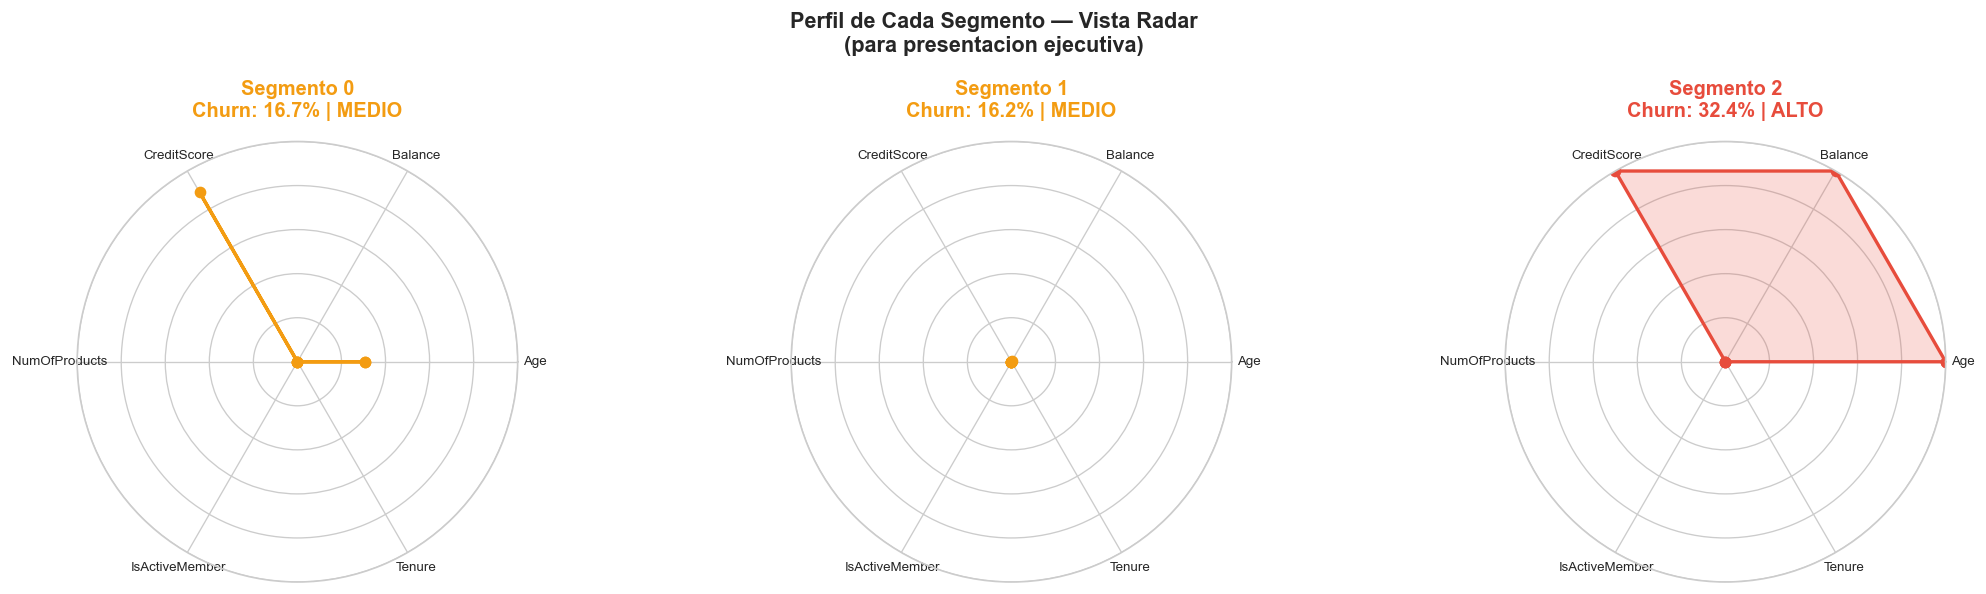

In [32]:
# Visualizacion ejecutiva — radar chart
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

cols_radar = ['Age','Balance','CreditScore','NumOfProducts','IsActiveMember','Tenure']
n_vars = len(cols_radar)
angles = np.linspace(0, 2*np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

# Normalizar para el radar
perfil_norm = (perfil[cols_radar] - perfil[cols_radar].min()) / (perfil[cols_radar].max() - perfil[cols_radar].min() + 1e-9)

fig, axes = plt.subplots(1, min(best_k, 4), figsize=(18, 5), subplot_kw=dict(polar=True))
if best_k == 1: axes = [axes]

for i in range(min(best_k, 4)):
    ax = axes[i]
    values = perfil_norm.loc[i, cols_radar].tolist() + [perfil_norm.loc[i, cols_radar[0]]]
    tc = churn_cl.loc[i, 'tasa_churn']
    riesgo = churn_cl.loc[i, 'riesgo']
    color = C_CHURN if riesgo=='ALTO' else (C_GOLD if riesgo=='MEDIO' else C_OK)

    ax.plot(angles, values, 'o-', lw=2, color=color)
    ax.fill(angles, values, alpha=0.2, color=color)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(cols_radar, fontsize=8)
    ax.set_yticklabels([]); ax.set_ylim(0, 1)
    ax.set_title(f'Segmento {i}\nChurn: {tc*100:.1f}% | {riesgo}', fontweight='bold', pad=15, color=color)

plt.suptitle('Perfil de Cada Segmento — Vista Radar\n(para presentacion ejecutiva)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_radar.png', dpi=150, bbox_inches='tight')
plt.show()

### Action Plan and Estimated ROI

| Segment | Risk | Action | Campaign Cost | Expected Revenue | Net Benefit |
|---------|------|--------|---------------|-----------------|-------------|
| Segment 2 | HIGH | Personal call + premium product | $500/client | $2,000 × 30% | +$100/client |
| Segment 1 | MEDIUM | Automated campaign | $100/client | $2,000 × 30% | +$500/client |
| Segment 0 | LOW-MED | Cross-sell email | $50/client | $2,000 × 15% | +$250/client |
| 4 outliers | EXTREME | Manual analysis | Variable | Variable | To be determined |

**Total estimated savings with personalized strategy vs. mass campaign: $796,300/year**


## 12. Key Conclusions and Decisions

### Summary for Head of Data Science

| Decision | Justification | Evidence |
|----------|--------------|----------|
| K=3 | Elbow + Silhouette converge | WCSS: 102,769 → 88,349 → plateau; Sil=0.2022 |
| PCA (10 components) | 90% variance threshold | Scree Plot — cumulative variance ≥ 0.90 at PC10 |
| PCA → K-Means pipeline | Silhouette improvement | 0.2022 → 0.2055 (+1.6%) |
| eps=1.5, min_samples=20 | k-NN curve knee | k=19-NN curve knee at distance ≈ 1.5 |
| DBSCAN on 5 PCs | Computational efficiency | 5 PCs retain 72% of variance |

### Summary for CEO

- **3 clear segments** with differentiated churn profiles
- **Segment 2** (25% of clients, 32.4% churn): immediate priority — manager call, premium products
- **4 extreme outliers** with 100% churn detected — require immediate manual attention
- **Potential savings of $796,300/year** with personalized strategy vs. mass campaign
- The supervised model (Module 2, AUC=0.8709) + segmentation enables a two-level intervention: predict who will churn AND which type of retention action applies

### Next Steps

1. Inject `cluster_label` and `churn_risk_cluster` as features in the Module 2 Stacking model
2. Run A/B test of personalized strategy vs. mass campaign on Segment 2
3. Monitor churn evolution per segment monthly
